# Experiment 3.0.5 — Frozen Representation Accessibility

Analysis-only notebook. The Slurm array performs frozen feature extraction and probe fitting; this notebook reads finalized artifacts only.

In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import pandas as pd

def find_repo_root(start=Path.cwd()):
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'snn').is_dir() and (candidate / 'notebooks').is_dir():
            return candidate
    raise FileNotFoundError('Could not locate writingRing repository root')

REPO_ROOT = find_repo_root()
ROOT = REPO_ROOT / 'notebooks/artifacts/experiment_3_0_5_frozen_representation_accessibility/frozen_access_v1'
ROOT

PosixPath('/home/zhaolongwei_umass_edu/projects/writingRing/notebooks/artifacts/experiment_3_0_5_frozen_representation_accessibility/frozen_access_v1')

In [2]:
probes = pd.read_csv(ROOT / 'experiment_3_0_5_probe_summary.csv')
derived = pd.read_csv(ROOT / 'experiment_3_0_5_derived_summary.csv')
selection = pd.read_csv(ROOT / 'experiment_3_0_5_objective_selection.csv')
with (ROOT / 'selected_backbone.json').open() as f:
    selected = json.load(f)
display(probes)
display(derived)
display(selection)
selected

,objective,probe_type,mean_probe_val_balanced_accuracy,sd_probe_val_balanced_accuracy,mean_probe_test_balanced_accuracy,sd_probe_test_balanced_accuracy,mean_probe_test_macro_f1,sd_probe_test_macro_f1
0,fixed250_sequence_ce,duration_only,0.131944,0.000000,0.113095,0.000000,0.033779,0.000000
1,fixed250_sequence_ce,fixed250_ordered,0.550776,0.037351,0.491647,0.003816,0.494627,0.010619
2,fixed250_sequence_ce,fixed250_pca128,0.487368,0.018530,0.458231,0.004796,0.453092,0.002856
3,fixed250_sequence_ce,fixed250_shuffled,0.348473,0.055061,0.310690,0.041252,0.285975,0.039327
4,fixed250_sequence_ce,full_count,0.454628,0.036038,0.441928,0.020921,0.437934,0.029956
5,fixed250_sequence_ce,relative10_ordered,0.622996,0.008544,0.635776,0.007186,0.636012,0.010931
6,fixed250_sequence_ce,relative10_pca128,0.593595,0.005221,0.617924,0.023049,0.617949,0.025708
7,fixed250_sequence_ce,relative10_shuffled,0.340693,0.018329,0.370614,0.042031,0.354062,0.037133
8,relative10_sequence_ce,duration_only,0.131944,0.000000,0.113095,0.000000,0.033779,0.000000
9,relative10_sequence_ce,fixed250_ordered,0.531938,0.003909,0.530732,0.033262,0.536024,0.037042


,objective,mean_absolute_time_position_gain_ba,sd_absolute_time_position_gain_ba,mean_relative_phase_position_gain_ba,sd_relative_phase_position_gain_ba,mean_posthoc_linear_accessibility_gap_ba,sd_posthoc_linear_accessibility_gap_ba,mean_duration_only_ba,sd_duration_only_ba
0,fixed250_sequence_ce,0.180957,0.037573,0.265162,0.045744,0.139027,0.012624,0.113095,0.0
1,relative10_sequence_ce,0.188030,0.070149,0.276851,0.068425,-0.004189,0.018871,0.113095,0.0
2,timestep_ce,0.110421,0.020757,0.122987,0.046811,0.202762,0.035522,0.113095,0.0


,objective,mean_probe_val_balanced_accuracy,sd_probe_val_balanced_accuracy
0,timestep_ce,0.551713,0.036897
1,fixed250_sequence_ce,0.511863,0.066150
2,relative10_sequence_ce,0.504548,0.075186


{'experiment_id': 'experiment_3_0_5_frozen_representation_accessibility',
 'protocol_version': 'frozen_access_v1',
 'seeds': [11, 23, 101],
 'selected_objective': 'timestep_ce',
 'selection_metric': 'mean validation BA across common dimension-matched probes',
 'selection_probes': ['full_count', 'fixed250_pca128', 'relative10_pca128'],
 'source_architecture': 'B',
 'source_experiment_id': 'experiment_3_0_3_l3_bottleneck_ablation',
 'source_width': 128}

probe_type,duration_only,fixed250_ordered,fixed250_pca128,fixed250_shuffled,full_count,relative10_ordered,relative10_pca128,relative10_shuffled
objective,,,,,,,,
fixed250_sequence_ce,0.113095,0.491647,0.458231,0.310690,0.441928,0.635776,0.617924,0.370614
relative10_sequence_ce,0.113095,0.530732,0.510601,0.342702,0.463900,0.672199,0.644142,0.395348
timestep_ce,0.113095,0.625945,0.590997,0.515524,0.559237,0.682000,0.677476,0.559013


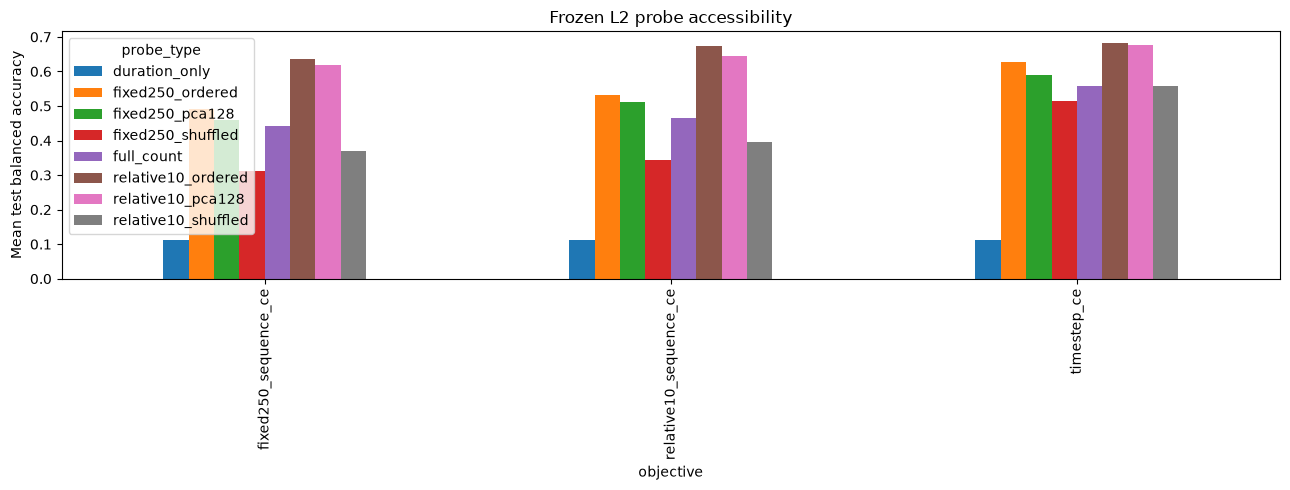

In [3]:
pivot = probes.pivot(index='objective', columns='probe_type', values='mean_probe_test_balanced_accuracy')
display(pivot)
ax = pivot.plot(kind='bar', figsize=(13, 5))
ax.set_ylabel('Mean test balanced accuracy')
ax.set_title('Frozen L2 probe accessibility')
plt.tight_layout()
plt.show()